
<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=0F5298 size=7>
Probability and Statistics (25732) <br>
<font color=2565AE size=5>
Electrical Engineering Department <br>

<font color=3C99D size=5>
CODES - Fall 2024<br>

<font color=696880 size=4>
Amitis Mirabedini (402102562) - Aynaz Rezaizadeh(402101822)    


# Edge Computing System Simulation

Simulation and performance analysis of a multi-layer IoT architecture using queueing theory and stochastic modeling.

Sharif University of Technology  
Engineering Probability and Statistics  
Winter 1403


# Q1

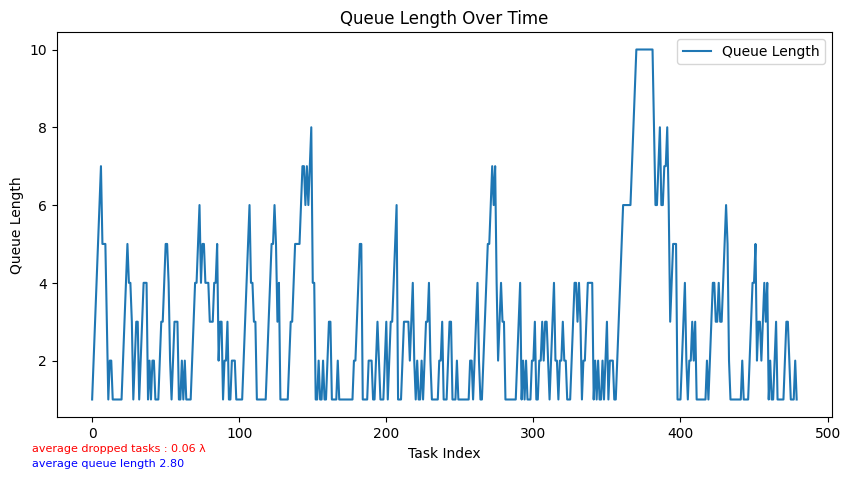

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

LAMBDA = 5  
MU = 7     
QUEUE_CAPACITY = 10 
SIM_TIME = 100  

def poisson_process(lmbda, time_limit):
    """Generate arrival times based on a Poisson process."""
    arrivals = []
    time = 0
    while time < time_limit:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        if time < time_limit:
            arrivals.append(time)
    return arrivals

def simulate_queue(lmbda, mu, queue_capacity, sim_time):
    """Simulate the edge server queue with Poisson arrivals and exponential service times."""
    arrivals = poisson_process(lmbda, sim_time)
    queue = []
    service_times = np.random.exponential(1 / mu, len(arrivals))
    queue_length = []
    dropped_tasks = 0
    current_time = 0
    departure_time = 0

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time = service_times[i]

        while queue and queue[0] <= arrival_time:
            queue.pop(0)

        if len(queue) < queue_capacity:
            departure_time = max(arrival_time, departure_time) + service_time
            queue.append(departure_time)
        else:
            dropped_tasks += 1 
       
        queue_length.append(len(queue))

    return queue_length, dropped_tasks

queue_lengths, dropped_tasks = simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, SIM_TIME)

average_queue_length = np.mean(queue_lengths)
average_dropped_tasks = dropped_tasks / SIM_TIME  

plt.figure(figsize=(10, 5))
plt.plot(queue_lengths, label="Queue Length")
plt.xlabel("Task Index")
plt.ylabel("Queue Length")
plt.title("Queue Length Over Time")
plt.legend()

plt.figtext(0.1, 0.01, f"average queue length {average_queue_length:.2f}", fontsize=8, color="blue")
plt.figtext(0.1, 0.04, f"average dropped tasks : {average_dropped_tasks:.2f} λ", fontsize=8, color="red")

plt.show()



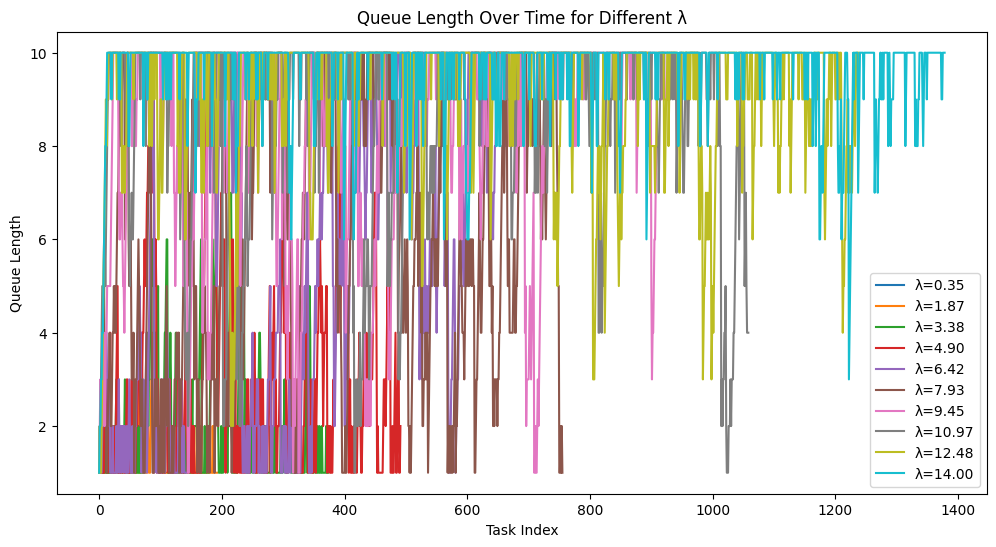

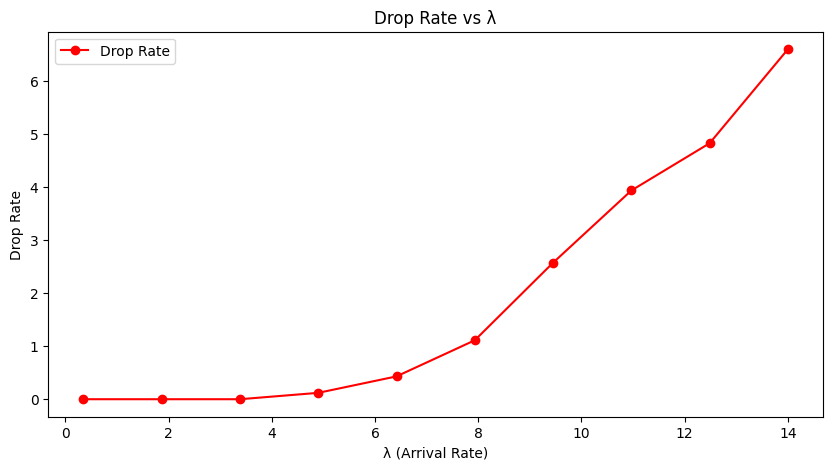

In [36]:
import numpy as np
import random
import matplotlib.pyplot as plt

MU = 7
QUEUE_CAPACITY = 10 
SIM_TIME = 100 
LAMBDA_VALUES = np.linspace(0.05 * MU, 2 * MU, 10)  

def poisson_process(lmbda, time_limit):
    arrivals = []
    time = 0
    while time < time_limit:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        if time < time_limit:
            arrivals.append(time)
    return arrivals

def simulate_queue(lmbda, mu, queue_capacity, sim_time):
    arrivals = poisson_process(lmbda, sim_time)
    queue = []
    service_times = np.random.exponential(1 / mu, len(arrivals))
    queue_length = []
    dropped_tasks = 0
    current_time = 0
    departure_time = 0

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time = service_times[i]

        while queue and queue[0] <= arrival_time:
            queue.pop(0)

        if len(queue) < queue_capacity:
            departure_time = max(arrival_time, departure_time) + service_time
            queue.append(departure_time)
        else:
            dropped_tasks += 1  
       
        queue_length.append(len(queue))

    return queue_length, dropped_tasks / sim_time 

plt.figure(figsize=(12, 6))

for LAMBDA in LAMBDA_VALUES:
    queue_lengths, drop_rate = simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, SIM_TIME)
   
    plt.plot(queue_lengths, label=f"λ={LAMBDA:.2f}")

plt.xlabel("Task Index")
plt.ylabel("Queue Length")
plt.title("Queue Length Over Time for Different λ")
plt.legend()
plt.show()

drop_rates = [simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, SIM_TIME)[1] for LAMBDA in LAMBDA_VALUES]

plt.figure(figsize=(10, 5))
plt.plot(LAMBDA_VALUES, drop_rates, marker='o', linestyle='-', color='r', label="Drop Rate")
plt.xlabel("λ (Arrival Rate)")
plt.ylabel("Drop Rate")
plt.title("Drop Rate vs λ")
plt.legend()
plt.show()


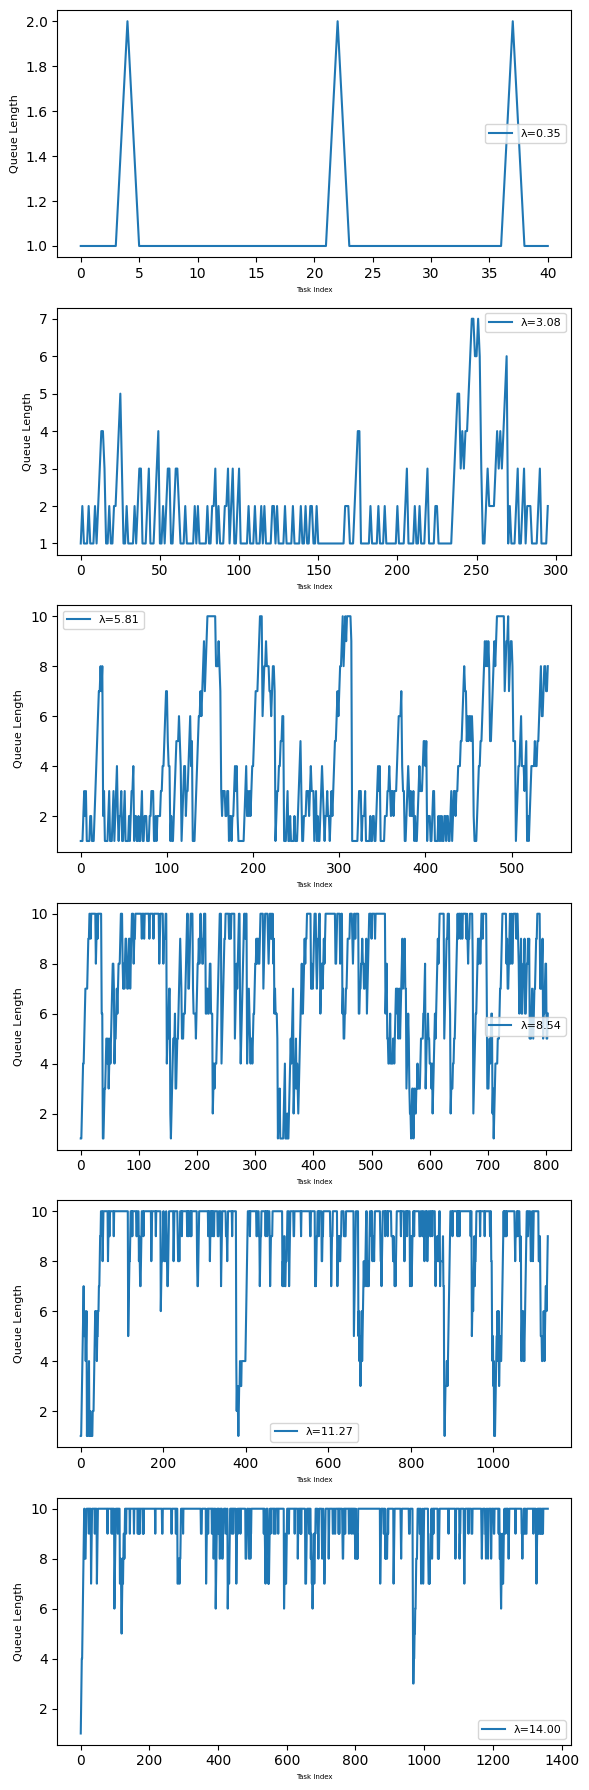

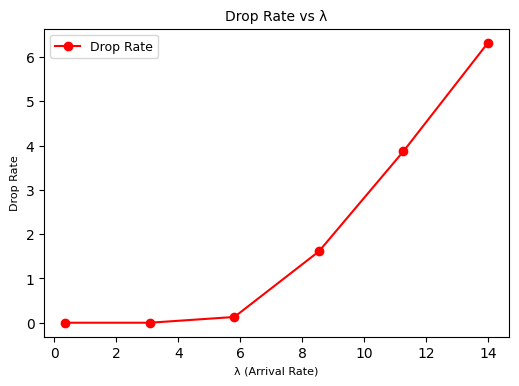

In [37]:
import numpy as np
import random
import matplotlib.pyplot as plt

MU = 7  
QUEUE_CAPACITY = 10 
SIM_TIME = 100 
LAMBDA_VALUES = np.linspace(0.05 * MU, 2 * MU, 6)

def poisson_process(lmbda, time_limit):
    """Generate arrival times based on a Poisson process."""
    arrivals = []
    time = 0
    while time < time_limit:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        if time < time_limit:
            arrivals.append(time)
    return arrivals

def simulate_queue(lmbda, mu, queue_capacity, sim_time):
    """Simulate the edge server queue with Poisson arrivals and exponential service times."""
    arrivals = poisson_process(lmbda, sim_time)
    queue = []
    service_times = np.random.exponential(1 / mu, len(arrivals))
    queue_length = []
    dropped_tasks = 0
    current_time = 0
    departure_time = 0

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time = service_times[i]

        while queue and queue[0] <= arrival_time:
            queue.pop(0)

        if len(queue) < queue_capacity:
            departure_time = max(arrival_time, departure_time) + service_time
            queue.append(departure_time)
        else:
            dropped_tasks += 1 
       
        queue_length.append(len(queue))

    return queue_length, dropped_tasks / sim_time  

fig, axes = plt.subplots(len(LAMBDA_VALUES), 1, figsize=(6, 3 * len(LAMBDA_VALUES)))

for i, LAMBDA in enumerate(LAMBDA_VALUES):
    queue_lengths, drop_rate = simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, SIM_TIME)
   
    axes[i].plot(queue_lengths, label=f"λ={LAMBDA:.2f}")
    axes[i].set_xlabel("Task Index", fontsize=5)
    axes[i].set_ylabel("Queue Length", fontsize=8)
   
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

drop_rates = [simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, SIM_TIME)[1] for LAMBDA in LAMBDA_VALUES]

plt.figure(figsize=(6, 4))
plt.plot(LAMBDA_VALUES, drop_rates, marker='o', linestyle='-', color='r', label="Drop Rate")
plt.xlabel("λ (Arrival Rate)", fontsize=8)
plt.ylabel("Drop Rate", fontsize=8)
plt.title("Drop Rate vs λ", fontsize=10)
plt.legend(fontsize=9)
plt.show()


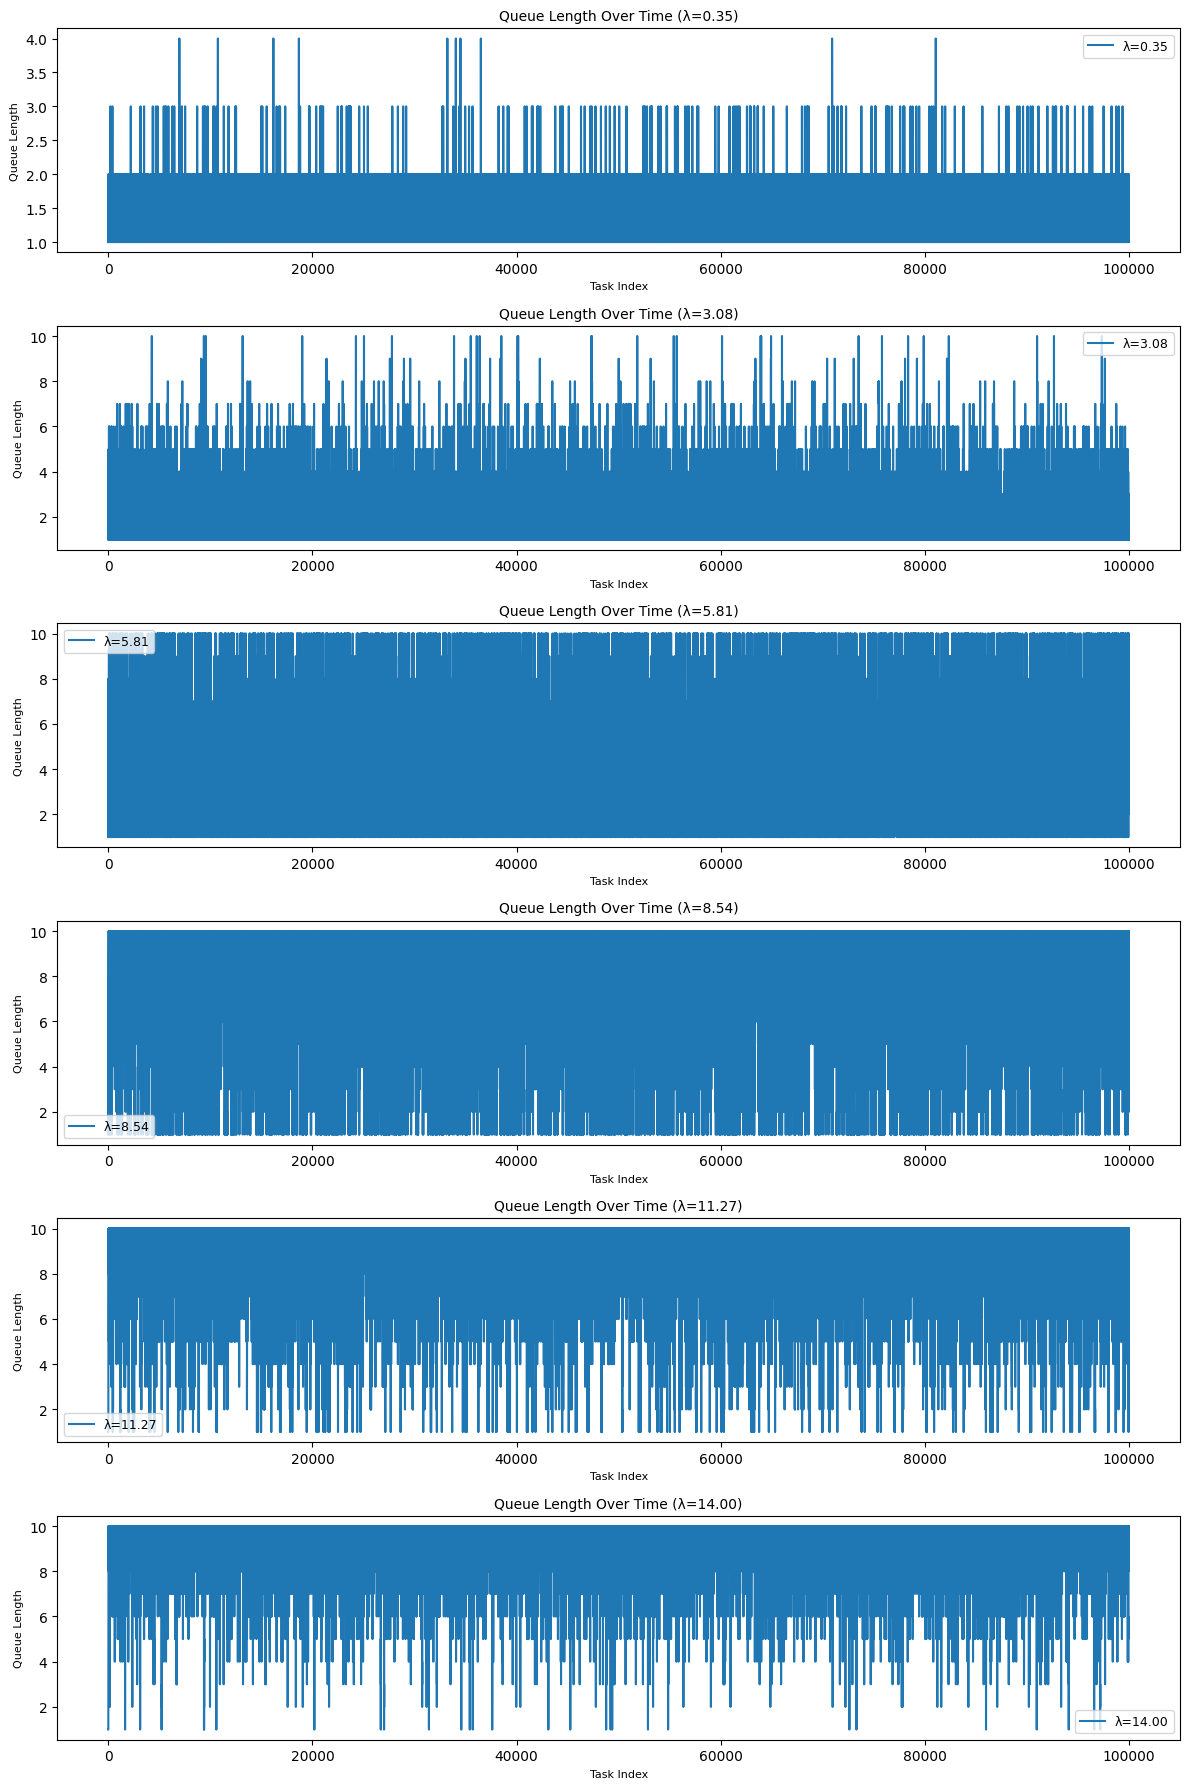

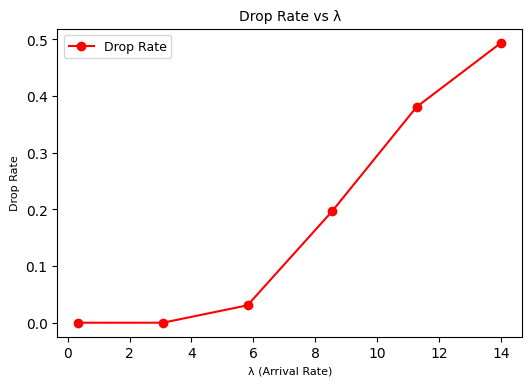

In [57]:
import numpy as np
import random
import matplotlib.pyplot as plt

MU = 7 
QUEUE_CAPACITY = 10  
N = 100000  
LAMBDA_VALUES = np.linspace(0.05 * MU, 2 * MU, 6) 

def poisson_process(lmbda, n_tasks):
    """Generate exactly n_tasks Poisson arrivals."""
    arrivals = []
    time = 0
    while len(arrivals) < n_tasks:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        arrivals.append(time)
    return arrivals

def simulate_queue(lmbda, mu, queue_capacity, n_tasks):
    """Simulate the edge server queue with Poisson arrivals and exponential service times."""
    arrivals = poisson_process(lmbda, n_tasks)  
    queue = []
    service_times = np.random.exponential(1 / mu, n_tasks)  
    queue_length = []
    dropped_tasks = 0
    current_time = 0
    departure_time = 0

    for i in range(n_tasks):
        arrival_time = arrivals[i]
        service_time = service_times[i]

        while queue and queue[0] <= arrival_time:
            queue.pop(0)

        if len(queue) < queue_capacity:
            departure_time = max(arrival_time, departure_time) + service_time
            queue.append(departure_time)
        else:
            dropped_tasks += 1  

        queue_length.append(len(queue))

    return queue_length, dropped_tasks / n_tasks  

fig, axes = plt.subplots(len(LAMBDA_VALUES), 1, figsize=(12, 3 * len(LAMBDA_VALUES)))

for i, LAMBDA in enumerate(LAMBDA_VALUES):
    queue_lengths, drop_rate = simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, N)
   
    axes[i].plot(queue_lengths, label=f"λ={LAMBDA:.2f}")
    axes[i].set_xlabel("Task Index", fontsize=8)
    axes[i].set_ylabel("Queue Length", fontsize=8)
    axes[i].legend(fontsize=9)
    axes[i].set_title(f"Queue Length Over Time (λ={LAMBDA:.2f})", fontsize=10)

plt.tight_layout()
plt.show()

drop_rates = [simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, N)[1] for LAMBDA in LAMBDA_VALUES]

plt.figure(figsize=(6, 4))
plt.plot(LAMBDA_VALUES, drop_rates, marker='o', linestyle='-', color='r', label="Drop Rate")
plt.xlabel("λ (Arrival Rate)", fontsize=8)
plt.ylabel("Drop Rate", fontsize=8)
plt.title("Drop Rate vs λ", fontsize=10)
plt.legend(fontsize=9)
plt.show()


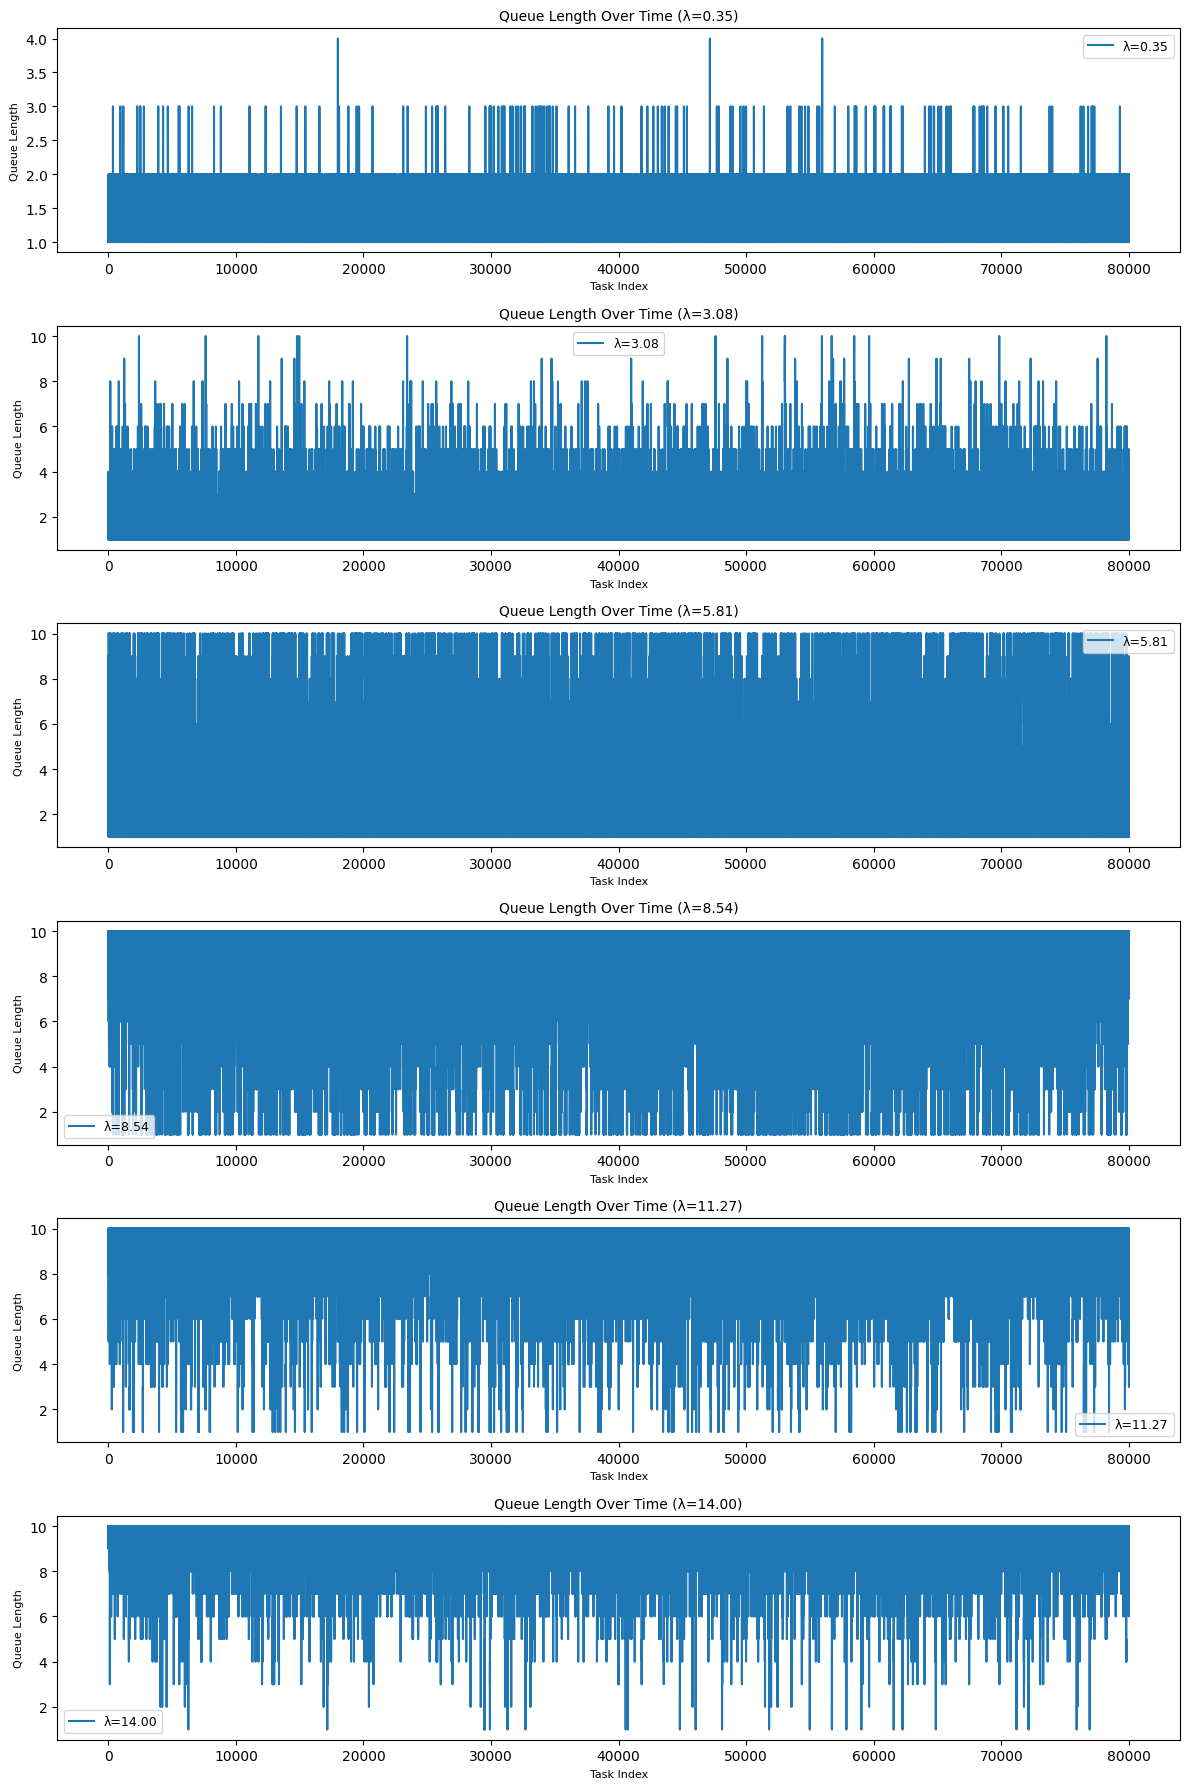

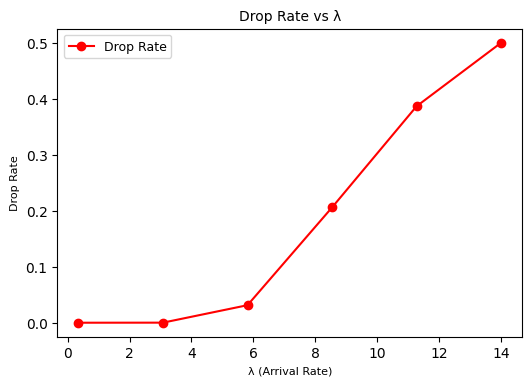

In [56]:
import numpy as np
import random
import matplotlib.pyplot as plt

MU = 7  
QUEUE_CAPACITY = 10  
N = 100000  
LAMBDA_VALUES = np.linspace(0.05 * MU, 2 * MU, 6) 

def poisson_process(lmbda, n_tasks):
    arrivals = []
    time = 0
    while len(arrivals) < n_tasks:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        arrivals.append(time)
    return arrivals

def simulate_queue(lmbda, mu, queue_capacity, n_tasks):
    arrivals = poisson_process(lmbda, n_tasks)  
    queue = []
    service_times = np.random.exponential(1 / mu, n_tasks)  
    queue_length = []
    dropped_tasks = 0
    current_time = 0
    departure_time = 0

    for i in range(n_tasks):
        arrival_time = arrivals[i]
        service_time = service_times[i]

        while queue and queue[0] <= arrival_time:
            queue.pop(0)

        if len(queue) < queue_capacity:
            departure_time = max(arrival_time, departure_time) + service_time
            queue.append(departure_time)
        else:
            dropped_tasks += 1 

        queue_length.append(len(queue))

    steady_state_queue = queue_length[int(0.2 * len(queue_length)):]

    return steady_state_queue, dropped_tasks / n_tasks  

fig, axes = plt.subplots(len(LAMBDA_VALUES), 1, figsize=(12, 3 * len(LAMBDA_VALUES)))

for i, LAMBDA in enumerate(LAMBDA_VALUES):
    queue_lengths, drop_rate = simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, N)
   
    axes[i].plot(queue_lengths, label=f"λ={LAMBDA:.2f}")
    axes[i].set_xlabel("Task Index", fontsize=8)
    axes[i].set_ylabel("Queue Length", fontsize=8)
    axes[i].legend(fontsize=9)
    axes[i].set_title(f"Queue Length Over Time (λ={LAMBDA:.2f})", fontsize=10)

plt.tight_layout()
plt.show()

drop_rates = [simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, N)[1] for LAMBDA in LAMBDA_VALUES]

plt.figure(figsize=(6, 4))
plt.plot(LAMBDA_VALUES, drop_rates, marker='o', linestyle='-', color='r', label="Drop Rate")
plt.xlabel("λ (Arrival Rate)", fontsize=8)
plt.ylabel("Drop Rate", fontsize=8)
plt.title("Drop Rate vs λ", fontsize=10)
plt.legend(fontsize=9)
plt.show()


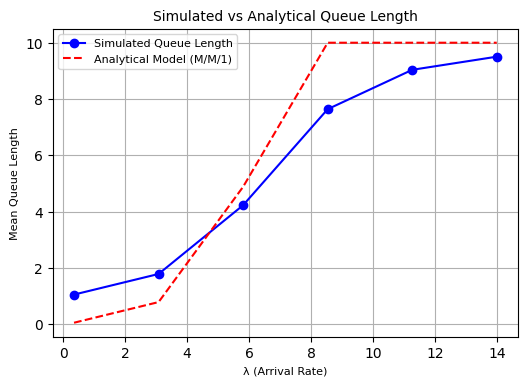

In [39]:
import numpy as np
import random
import matplotlib.pyplot as plt

MU = 7  
QUEUE_CAPACITY = 10 
SIM_TIME = 1000000  
LAMBDA_VALUES = np.linspace(0.05 * MU, 2 * MU, 6)  # 6 values for λ

def poisson_process(lmbda, time_limit):
    """Generate Poisson arrival times."""
    arrivals = []
    time = 0
    while time < time_limit:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        if time < time_limit:
            arrivals.append(time)
    return arrivals

def simulate_queue(lmbda, mu, queue_capacity, sim_time):
    """Simulate edge server queue with Poisson arrivals and exponential service times."""
    arrivals = poisson_process(lmbda, sim_time)
    queue = []
    service_times = np.random.exponential(1 / mu, len(arrivals))
    queue_length = []
    dropped_tasks = 0
    departure_time = 0

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time = service_times[i]

        while queue and queue[0] <= arrival_time:
            queue.pop(0)

        if len(queue) < queue_capacity:
            departure_time = max(arrival_time, departure_time) + service_time
            queue.append(departure_time)
        else:
            dropped_tasks += 1 
       
        queue_length.append(len(queue))

    steady_state_queue = queue_length[int(0.2 * len(queue_length)):]
   
    return np.mean(steady_state_queue), dropped_tasks / sim_time

mean_queue_lengths = []
analytical_queue_lengths = []
drop_rates = []

for LAMBDA in LAMBDA_VALUES:
    mean_queue, drop_rate = simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, SIM_TIME)
   
    if LAMBDA < MU:
        analytical_queue = LAMBDA / (MU - LAMBDA)
    else:
        analytical_queue = QUEUE_CAPACITY 
   
    mean_queue_lengths.append(mean_queue)
    analytical_queue_lengths.append(analytical_queue)
    drop_rates.append(drop_rate)

plt.figure(figsize=(6, 4))
plt.plot(LAMBDA_VALUES, mean_queue_lengths, 'bo-', label="Simulated Queue Length")
plt.plot(LAMBDA_VALUES, analytical_queue_lengths, 'r--', label="Analytical Model (M/M/1)")
plt.xlabel("λ (Arrival Rate)", fontsize=8)
plt.ylabel("Mean Queue Length", fontsize=8)
plt.title("Simulated vs Analytical Queue Length", fontsize=10)
plt.legend(fontsize=8)
plt.grid()
plt.show()


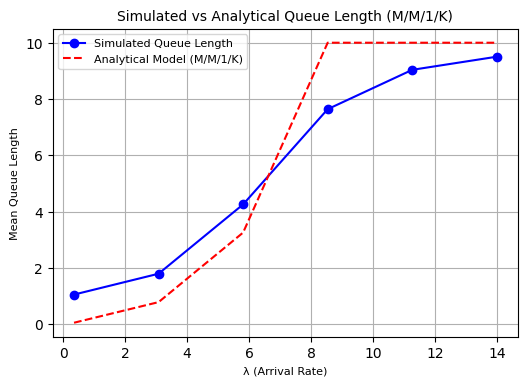

In [86]:
import numpy as np
import random
import matplotlib.pyplot as plt

MU = 7  
QUEUE_CAPACITY = 10  
SIM_TIME = 100000 
LAMBDA_VALUES = np.linspace(0.05 * MU, 2 * MU, 6)  

def poisson_process(lmbda, time_limit):
    """Generate Poisson arrival times."""
    arrivals = []
    time = 0
    while time < time_limit:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        if time < time_limit:
            arrivals.append(time)
    return arrivals

def simulate_queue(lmbda, mu, queue_capacity, sim_time):
    """Simulate edge server queue with Poisson arrivals and exponential service times."""
    arrivals = poisson_process(lmbda, sim_time)
    queue = []
    service_times = np.random.exponential(1 / mu, len(arrivals))
    queue_length = []
    dropped_tasks = 0
    departure_time = 0

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time = service_times[i]

        while queue and queue[0] <= arrival_time:
            queue.pop(0)

        if len(queue) < queue_capacity:
            departure_time = max(arrival_time, departure_time) + service_time
            queue.append(departure_time)
        else:
            dropped_tasks += 1  
       
        queue_length.append(len(queue))

    steady_state_queue = queue_length[int(0.2 * len(queue_length)):]
   
    return np.mean(steady_state_queue), dropped_tasks / sim_time

def analytical_mm1k(lmbda, mu, K):
    """Compute the analytical mean queue length for an M/M/1/K system."""
    rho = lmbda / mu
    if rho == 1:
        return K / 2 
    elif rho < 1:
        numerator = rho * (1 - (K + 1) * rho**K + K * rho**(K+1))
        denominator = (1 - rho) * (1 - rho**(K+1))
        return numerator / denominator
    else:
        return K  

mean_queue_lengths = []
analytical_queue_lengths = []
drop_rates = []

for LAMBDA in LAMBDA_VALUES:
    mean_queue, drop_rate = simulate_queue(LAMBDA, MU, QUEUE_CAPACITY, SIM_TIME)
   
    analytical_queue = analytical_mm1k(LAMBDA, MU, QUEUE_CAPACITY)

    mean_queue_lengths.append(mean_queue)
    analytical_queue_lengths.append(analytical_queue)
    drop_rates.append(drop_rate)

plt.figure(figsize=(6, 4))
plt.plot(LAMBDA_VALUES, mean_queue_lengths, 'bo-', label="Simulated Queue Length")
plt.plot(LAMBDA_VALUES, analytical_queue_lengths, 'r--', label="Analytical Model (M/M/1/K)")
plt.xlabel("λ (Arrival Rate)", fontsize=8)
plt.ylabel("Mean Queue Length", fontsize=8)
plt.title("Simulated vs Analytical Queue Length (M/M/1/K)", fontsize=10)
plt.legend(fontsize=8)
plt.grid()
plt.show()


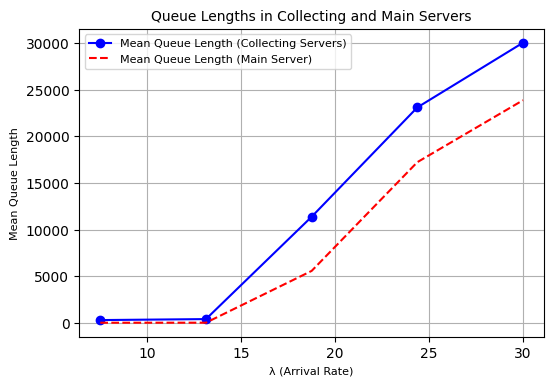

In [50]:

import numpy as np
import random
import matplotlib.pyplot as plt

NUM_COLLECTING_SERVERS = 3  
MU_COLLECTING = 5           
MU_MAIN = NUM_COLLECTING_SERVERS * MU_COLLECTING 
SIM_TIME = 100000         
P_RETURN = 0.1            
LAMBDA_VALUES = np.linspace(0.5 * MU_MAIN, 2 * MU_MAIN, 5)  

def poisson_process(lmbda, n_tasks):
    """Generate Poisson arrival times."""
    arrivals = []
    time = 0
    while len(arrivals) < n_tasks:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        arrivals.append(time)
    return arrivals

def simulate_collecting_system(lmbda, mu_collecting, mu_main, num_collecting, p_return, sim_time):
    """Simulate a system with multiple collecting servers and one main server."""
    arrivals = poisson_process(lmbda, sim_time)
    collecting_queues = [[] for _ in range(num_collecting)]
    main_queue = []
    service_times_collecting = np.random.exponential(1 / mu_collecting, len(arrivals))
    service_times_main = np.random.exponential(1 / mu_main, len(arrivals))

    queue_lengths_collecting = []
    queue_lengths_main = []
    current_time = 0
    departure_time_main = 0

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time_collecting = service_times_collecting[i]
        service_time_main = service_times_main[i]

        min_queue_index = np.argmin([len(q) for q in collecting_queues])
        collecting_queue = collecting_queues[min_queue_index]

        while collecting_queue and collecting_queue[0] <= arrival_time:
            collecting_queue.pop(0)

        departure_time_collecting = max(arrival_time, collecting_queue[-1] if collecting_queue else arrival_time) + service_time_collecting
        collecting_queue.append(departure_time_collecting)

        if random.random() > p_return:
            while main_queue and main_queue[0] <= arrival_time:
                main_queue.pop(0)

            departure_time_main = max(arrival_time, departure_time_main) + service_time_main
            main_queue.append(departure_time_main)

        queue_lengths_collecting.append(sum(len(q) for q in collecting_queues))
        queue_lengths_main.append(len(main_queue))

    steady_state_collecting = queue_lengths_collecting[int(0.2 * len(queue_lengths_collecting)):]
    steady_state_main = queue_lengths_main[int(0.2 * len(queue_lengths_main)):]

    return np.mean(steady_state_collecting), np.mean(steady_state_main)

mean_queue_lengths_collecting = []
mean_queue_lengths_main = []

for LAMBDA in LAMBDA_VALUES:
    mean_collecting, mean_main = simulate_collecting_system(
        LAMBDA, MU_COLLECTING, MU_MAIN, NUM_COLLECTING_SERVERS, P_RETURN, SIM_TIME
    )
    mean_queue_lengths_collecting.append(mean_collecting)
    mean_queue_lengths_main.append(mean_main)

plt.figure(figsize=(6, 4))
plt.plot(LAMBDA_VALUES, mean_queue_lengths_collecting, 'bo-', label="Mean Queue Length (Collecting Servers)")
plt.plot(LAMBDA_VALUES, mean_queue_lengths_main, 'r--', label="Mean Queue Length (Main Server)")
plt.xlabel("λ (Arrival Rate)", fontsize=8)
plt.ylabel("Mean Queue Length", fontsize=8)
plt.title("Queue Lengths in Collecting and Main Servers", fontsize=10)
plt.legend(fontsize=8)
plt.grid()
plt.show()


### Q3

In [ ]:
import numpy as np
import random

def poisson_process(lmbda, n_tasks):
    arrivals = []
    time = 0
    while len(arrivals) < n_tasks:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        arrivals.append(time)
    return arrivals

def simulate_system(mu, lambd, k, p, n_tasks, num_collecting_servers, num_edge_servers):
    arrivals = poisson_process(lambd, n_tasks)
    edge_queues = [[] for _ in range(num_edge_servers)]
    collecting_queues = [[] for _ in range(num_collecting_servers)]
    main_queue = []

    dropped_tasks = 0
    returned_tasks = 0
    processed_tasks = 0
    total_tasks_processed = 0

    service_times_edge = np.random.exponential(1 / mu, len(arrivals))
    service_times_collecting = np.random.exponential(1 / mu, len(arrivals))
    service_times_main = np.random.exponential(1 / mu, len(arrivals))

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time_edge = service_times_edge[i]
        service_time_collecting = service_times_collecting[i]
        service_time_main = service_times_main[i]

        edge_server_index = i % num_edge_servers  
        edge_queue = edge_queues[edge_server_index]

        if len(edge_queue) < k:
            edge_queue.append(arrival_time + service_time_edge)
        else:
            dropped_tasks += 1  

        min_queue_index = np.argmin([len(q) for q in collecting_queues])
        collecting_queue = collecting_queues[min_queue_index]

        while collecting_queue and collecting_queue[0] <= arrival_time:
            collecting_queue.pop(0)

        if random.random() < p:  
            returned_tasks += 1
        else:
            processed_tasks += 1  

        while main_queue and main_queue[0] <= arrival_time:
            main_queue.pop(0)
        main_queue.append(arrival_time + service_time_main)

        total_tasks_processed += 1

    processed_tasks_after_transient = processed_tasks * 0.8
    drop_rate = dropped_tasks / (lambd * n_tasks)

    return processed_tasks_after_transient, returned_tasks, dropped_tasks, drop_rate

sim_params = [
    {'mu': 10, 'lambda': 3, 'k': 10, 'p': 0.1},
    {'mu': 10, 'lambda': 6, 'k': 10, 'p': 0.1},
    {'mu': 10, 'lambda': 9, 'k': 10, 'p': 0.1},
]

for idx, params in enumerate(sim_params, start=1):
    mu = params['mu']
    lambd = params['lambda']
    k = params['k']
    p = params['p']

    total_processed, returned_tasks, dropped_tasks, drop_rate = simulate_system(mu, lambd, k, p, 100000, 3, 15)

    throughput = total_processed / 100000  

    print(f"Scenario {idx}: λ = {lambd}, mu = {mu}, k = {k}, p = {p}")
    print(f"Throughput: {throughput:.4f}")
    print(f"Returned Tasks: {returned_tasks}")
    print(f"Dropped Tasks: {dropped_tasks}")
    print(f"Drop Rate: {drop_rate:.4f}")
    print("-" * 40)


   


Scenario 1: λ = 3, mu = 10, k = 10, p = 0.1
Throughput: 0.7207
Returned Tasks: 9911
Dropped Tasks: 99850
Drop Rate: 0.3328
----------------------------------------
Scenario 2: λ = 6, mu = 10, k = 10, p = 0.1
Throughput: 0.7198
Returned Tasks: 10022
Dropped Tasks: 99850
Drop Rate: 0.1664
----------------------------------------
Scenario 3: λ = 9, mu = 10, k = 10, p = 0.1
Throughput: 0.7195
Returned Tasks: 10061
Dropped Tasks: 99850
Drop Rate: 0.1109
----------------------------------------


In [ ]:
import numpy as np
import random

PARAMS = [
    {'mu': 10, 'lambda_': 3, 'k': 10, 'p': 0.1},
    {'mu': 10, 'lambda_': 6, 'k': 10, 'p': 0.1},
    {'mu': 10, 'lambda_': 9, 'k': 10, 'p': 0.1},
]

NUM_COLLECTING_SERVERS = 3
NUM_EDGE_SERVERS = 5
SIM_TIME = 100000 

def poisson_process(lmbda, n_tasks):
    """Generate Poisson arrival times."""
    arrivals = []
    time = 0
    while len(arrivals) < n_tasks:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        arrivals.append(time)
    return arrivals

def simulate_queue(lmbda, mu, k, sim_time):
    """Simulate the edge server queue with Poisson arrivals and exponential service times."""
    arrivals = poisson_process(lmbda, sim_time)
    queue = []
    service_times = np.random.exponential(1 / mu, len(arrivals))
    completed_tasks = 0
    dropped_tasks = 0
    queue_lengths = []

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time = service_times[i]

        while queue and queue[0] <= arrival_time:
            queue.pop(0)

        if len(queue) < k:
            departure_time = max(arrival_time, queue[-1] if queue else arrival_time) + service_time
            queue.append(departure_time)
            completed_tasks += 1
        else:
            dropped_tasks += 1

        queue_lengths.append(len(queue))

    return completed_tasks / sim_time, dropped_tasks

def simulate_collecting_system(lmbda, mu_collecting, mu_main, num_collecting, p, sim_time):
    """Simulate the system with multiple collecting servers and one main server."""
    arrivals = poisson_process(lmbda, sim_time)
    collecting_queues = [[] for _ in range(num_collecting)]
    main_queue = []
    service_times_collecting = np.random.exponential(1 / mu_collecting, len(arrivals))
    service_times_main = np.random.exponential(1 / mu_main, len(arrivals))

    queue_lengths_collecting = []
    queue_lengths_main = []
    completed_tasks = 0
    returned_tasks = 0
    current_time = 0
    departure_time_main = 0

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time_collecting = service_times_collecting[i]
        service_time_main = service_times_main[i]

        min_queue_index = np.argmin([len(q) for q in collecting_queues])
        collecting_queue = collecting_queues[min_queue_index]

        while collecting_queue and collecting_queue[0] <= arrival_time:
            collecting_queue.pop(0)

        departure_time_collecting = max(arrival_time, collecting_queue[-1] if collecting_queue else arrival_time) + service_time_collecting
        collecting_queue.append(departure_time_collecting)

        if random.random() > p:
            while main_queue and main_queue[0] <= arrival_time:
                main_queue.pop(0)

            departure_time_main = max(arrival_time, departure_time_main) + service_time_main
            main_queue.append(departure_time_main)

            completed_tasks += 1
        else:
            returned_tasks += 1

        queue_lengths_collecting.append(sum(len(q) for q in collecting_queues))
        queue_lengths_main.append(len(main_queue))

    steady_state_collecting = queue_lengths_collecting[int(0.2 * len(queue_lengths_collecting)):]
    steady_state_main = queue_lengths_main[int(0.2 * len(queue_lengths_main)):]

    return np.mean(steady_state_collecting), np.mean(steady_state_main), completed_tasks / sim_time, returned_tasks

exit_rates = []
returned_tasks_all = []
drop_rates_all = []

for params in PARAMS:
    exit_rate_edge, dropped_tasks = simulate_queue(params['lambda_'], params['mu'], params['k'], SIM_TIME)

    exit_rate_collecting, _, completed_tasks_rate, returned_tasks = simulate_collecting_system(
        params['lambda_'], params['mu'], params['mu'], NUM_COLLECTING_SERVERS, params['p'], SIM_TIME
    )

    total_exit_rate = exit_rate_edge + exit_rate_collecting

    drop_rate = dropped_tasks / (params['lambda_'] * SIM_TIME)

    exit_rates.append(total_exit_rate)
    returned_tasks_all.append(returned_tasks)
    drop_rates_all.append(drop_rate)

for i, params in enumerate(PARAMS):
    print(f"λ={params['lambda_']}, μ={params['mu']}, k={params['k']}, p={params['p']} -> Exit Rate: {exit_rates[i]:.4f}")
    print(f"  Returned Tasks: {returned_tasks_all[i]}")
    print(f"  Drop Rate: {drop_rates_all[i]:.4f}")

avg_exit_rate = np.mean(exit_rates)
avg_drop_rate = np.mean(drop_rates_all)

print(f"\nAverage Exit Rate: {avg_exit_rate:.4f}")
print(f"Average Drop Rate: {avg_drop_rate:.4f}")


λ=3, μ=10, k=10, p=0.1 -> Exit Rate: 19.2486
  Returned Tasks: 10207
  Drop Rate: 0.0000
λ=6, μ=10, k=10, p=0.1 -> Exit Rate: 32.9488
  Returned Tasks: 10141
  Drop Rate: 0.0003
λ=9, μ=10, k=10, p=0.1 -> Exit Rate: 75.5245
  Returned Tasks: 9966
  Drop Rate: 0.0055

Average Exit Rate: 42.5740
Average Drop Rate: 0.0020


Modeling Results:

In [36]:
import numpy as np
import random

PARAMS = [
    {'mu': 10, 'lambda_': 3, 'k': 10, 'p': 0.1},
    {'mu': 10, 'lambda_': 6, 'k': 10, 'p': 0.1},
    {'mu': 10, 'lambda_': 9, 'k': 10, 'p': 0.1},
]

NUM_COLLECTING_SERVERS = 3
NUM_EDGE_SERVERS = 5
SIM_TIME = 100000  

def poisson_process(lmbda, n_tasks):
    """Generate Poisson arrival times."""
    arrivals = []
    time = 0
    while len(arrivals) < n_tasks:
        inter_arrival = np.random.exponential(1 / lmbda)
        time += inter_arrival
        arrivals.append(time)
    return arrivals

def simulate_queue(lmbda, mu, k, sim_time):
    """Simulate the edge server queue with Poisson arrivals and exponential service times."""
    arrivals = poisson_process(lmbda, sim_time)
    queue = []
    service_times = np.random.exponential(1 / mu, len(arrivals))
    completed_tasks = 0
    dropped_tasks = 0
    queue_lengths = []

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time = service_times[i]

        while queue and queue[0] <= arrival_time:
            queue.pop(0)

        if len(queue) < k:
            departure_time = max(arrival_time, queue[-1] if queue else arrival_time) + service_time
            queue.append(departure_time)
            completed_tasks += 1
        else:
            dropped_tasks += 1

        queue_lengths.append(len(queue))

    return completed_tasks / sim_time, dropped_tasks  

def simulate_collecting_system(lmbda, mu_collecting, mu_main, num_collecting, p, sim_time):
    """Simulate the system with multiple collecting servers and one main server."""
    arrivals = poisson_process(lmbda, sim_time)
    collecting_queues = [[] for _ in range(num_collecting)]
    main_queue = []
    service_times_collecting = np.random.exponential(1 / mu_collecting, len(arrivals))
    service_times_main = np.random.exponential(1 / mu_main, len(arrivals))

    queue_lengths_collecting = []
    queue_lengths_main = []
    completed_tasks = 0
    returned_tasks = 0
    current_time = 0
    departure_time_main = 0

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time_collecting = service_times_collecting[i]
        service_time_main = service_times_main[i]

        min_queue_index = np.argmin([len(q) for q in collecting_queues])
        collecting_queue = collecting_queues[min_queue_index]

        while collecting_queue and collecting_queue[0] <= arrival_time:
            collecting_queue.pop(0)

        departure_time_collecting = max(arrival_time, collecting_queue[-1] if collecting_queue else arrival_time) + service_time_collecting
        collecting_queue.append(departure_time_collecting)

        if random.random() > p:
            while main_queue and main_queue[0] <= arrival_time:
                main_queue.pop(0)

            departure_time_main = max(arrival_time, departure_time_main) + service_time_main
            main_queue.append(departure_time_main)

            completed_tasks += 1
        else:
            returned_tasks += 1

        queue_lengths_collecting.append(sum(len(q) for q in collecting_queues))
        queue_lengths_main.append(len(main_queue))

    steady_state_collecting = queue_lengths_collecting[int(0.2 * len(queue_lengths_collecting)):]
    steady_state_main = queue_lengths_main[int(0.2 * len(queue_lengths_main)):]

    return np.mean(steady_state_collecting), np.mean(steady_state_main), completed_tasks / sim_time, returned_tasks

exit_rates = []
returned_tasks_all = []
drop_rates_all = []
edge_exit_rates = []

for params in PARAMS:
    edge_exit_rate, dropped_tasks = simulate_queue(params['lambda_'], params['mu'], params['k'], SIM_TIME)

    exit_rate_collecting, _, completed_tasks_rate, returned_tasks = simulate_collecting_system(
        params['lambda_'], params['mu'], params['mu'], NUM_COLLECTING_SERVERS, params['p'], SIM_TIME
    )

    total_exit_rate = edge_exit_rate + exit_rate_collecting

    drop_rate = dropped_tasks / (params['lambda_'] * SIM_TIME)

    exit_rates.append(total_exit_rate)
    returned_tasks_all.append(returned_tasks)
    drop_rates_all.append(drop_rate)
    edge_exit_rates.append(edge_exit_rate)

for i, params in enumerate(PARAMS):
    print(f"λ={params['lambda_']}, μ={params['mu']}, k={params['k']}, p={params['p']} -> Exit Rate: {exit_rates[i]:.4f}")
    print(f"  Edge Server Exit Rate: {edge_exit_rates[i]:.4f}")
    print(f"  Returned Tasks: {returned_tasks_all[i]}")
    print(f"  Drop Rate: {drop_rates_all[i]:.4f}")

avg_exit_rate = np.mean(exit_rates)
avg_drop_rate = np.mean(drop_rates_all)

print(f"\nAverage Exit Rate: {avg_exit_rate:.4f}")
print(f"Average Drop Rate: {avg_drop_rate:.4f}")


λ=3, μ=10, k=10, p=0.1 -> Exit Rate: 17.8388
  Edge Server Exit Rate: 1.0000
  Returned Tasks: 10004
  Drop Rate: 0.0000
λ=6, μ=10, k=10, p=0.1 -> Exit Rate: 32.6215
  Edge Server Exit Rate: 0.9982
  Returned Tasks: 9864
  Drop Rate: 0.0003
λ=9, μ=10, k=10, p=0.1 -> Exit Rate: 74.2189
  Edge Server Exit Rate: 0.9512
  Returned Tasks: 9930
  Drop Rate: 0.0054

Average Exit Rate: 41.5597
Average Drop Rate: 0.0019


### Q4

Modeling:

In [37]:
import numpy as np
from scipy.optimize import fsolve

def derivative_cost(mu, A, B):
    p_mu = 2 * (1 / (1 + np.exp(-0.25 * mu)) - 0.5)
    p_prime_mu = 0.5 * np.exp(-0.25 * mu) / (1 + np.exp(-0.25 * mu))**2
    
    term1 = 15 * (1 - p_mu) + 15 * mu * (-p_prime_mu)
    term1 = -A * term1 / (15 * mu * (1 - p_mu))**2
    
    term2 = B * p_prime_mu
    
    return term1 + term2

A_values = [0.5, 1, 1]
B_values = [1, 1, 0.5]

def find_optimal_mu(A, B):
    optimal_mu = fsolve(derivative_cost, x0=1, args=(A, B))
    return optimal_mu[0]

optimal_mu_values = [find_optimal_mu(A, B) for A, B in zip(A_values, B_values)]

p_mu_values = [2 * (1 / (1 + np.exp(-0.25 * mu)) - 0.5) for mu in optimal_mu_values]

for i, (A, B) in enumerate(zip(A_values, B_values)):
    print(f"For A = {A} and B = {B}:")
    print(f"Optimal mu = {optimal_mu_values[i]:.2f}")
    print(f"Corresponding p(mu) = {p_mu_values[i]:.3f}\n")


For A = 0.5 and B = 1:
Optimal mu = -0.52
Corresponding p(mu) = -0.064

For A = 1 and B = 1:
Optimal mu = 0.73
Corresponding p(mu) = 0.091

For A = 1 and B = 0.5:
Optimal mu = 1.03
Corresponding p(mu) = 0.128



Simulation:  

In [57]:
import numpy as np
import random

lambda_ = 2        
k = 10            
sim_time = 5000   

def poisson_process(lmbda, n_tasks):
    arrivals = []
    current_time = 0
    while len(arrivals) < n_tasks:
        inter_arrival = np.random.exponential(1 / lmbda)
        current_time += inter_arrival
        arrivals.append(current_time)
    return arrivals

def simulate_queue(lmbda, mu, k, sim_time):
   
    arrivals = poisson_process(lmbda, sim_time)
    if mu <= 0:
        return 0, sim_time
    service_times = np.random.exponential(1 / mu, len(arrivals))
    
    queue = []
    completed_tasks = 0
    dropped_tasks = 0

    for i in range(len(arrivals)):
        arrival_time = arrivals[i]
        service_time = service_times[i]
        
        while queue and queue[0] <= arrival_time:
            queue.pop(0)
        
        if len(queue) < k:
            departure_time = max(arrival_time, queue[-1] if queue else arrival_time) + service_time
            queue.append(departure_time)
            completed_tasks += 1
        else:
            dropped_tasks += 1

    return completed_tasks, dropped_tasks

cases = [
    {"A": 0.5, "B": 1,   "mu_range": np.arange(-0.60, -0.40 + 0.01, 0.01)},
    {"A": 1,   "B": 1,   "mu_range": np.arange(0.60,  0.77 + 0.01, 0.01)},
    {"A": 1,   "B": 0.5, "mu_range": np.arange(0.95,  1.05 + 0.01, 0.01)}
]


def calculate_cost(mu, A, B, lambda_, sim_time):
   
    _, dropped_tasks = simulate_queue(lambda_, mu, k, sim_time)
    
    p_mu = 2 * (1 / (1 + np.exp(-0.25 * mu)) - 0.5)
    
    returned_tasks = lambda_ * p_mu * sim_time
    
    total_cost = A * dropped_tasks + B * returned_tasks
    return total_cost

def find_optimal_mu(A, B, lambda_, sim_time, mu_range):
  
    min_cost = float('inf')
    optimal_mu = None
    for mu in mu_range:
        cost = calculate_cost(mu, A, B, lambda_, sim_time)
        if cost < min_cost:
            min_cost = cost
            optimal_mu = mu
    return optimal_mu, min_cost

for case in cases:
    A = case["A"]
    B = case["B"]
    mu_range_case = case["mu_range"]
    
    opt_mu, opt_cost = find_optimal_mu(A, B, lambda_, sim_time, mu_range_case)
    p_mu_opt = 2 * (1 / (1 + np.exp(-0.25 * opt_mu)) - 0.5)
    
    print(f"For A = {A} and B = {B}:")
    print(f"  Optimal mu = {opt_mu:.3f}")
    print(f"  p(mu) at optimal mu = {p_mu_opt:.3f}")
    print(f"  Total cost = {opt_cost:.3f}\n")


For A = 0.5 and B = 1:
  Optimal mu = -0.600
  p(mu) at optimal mu = -0.075
  Total cost = 1751.403

For A = 1 and B = 1:
  Optimal mu = 0.780
  p(mu) at optimal mu = 0.097
  Total cost = 3933.922

For A = 1 and B = 0.5:
  Optimal mu = 1.050
  p(mu) at optimal mu = 0.131
  Total cost = 2897.507



The simulation results are well in accordance to the modeling results.